<a href="https://colab.research.google.com/github/hamzafareed123/code-review-agent/blob/pr_verdict_node/code_review_agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [84]:
from google.colab import userdata

GITHUB_TOKEN = userdata.get("GITHUB-TOKEN")
GROQ_API_KEY=  userdata.get("GROQ_API_KEY")


In [ ]:
!pip install PyGithub langgraph langchain langchain-core langchain-community langchain-groq

In [86]:
from github import Github, Auth
from langgraph.graph import START,END,StateGraph
from typing import TypedDict,Literal
from pydantic import BaseModel,Field
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate

In [87]:
#==================================
#  LLM setup
#==================================

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=GROQ_API_KEY,
    temperature=0.2,
    max_tokens=3000
)

In [88]:
#==================================
#  Bug Finding Schema
#==================================


class BugFinding(BaseModel):
    file_name: str
    line_number: int
    severity: Literal["Critical", "Medium", "Low"]
    description: str
    recommendation: str
    has_bug:bool

In [89]:
#==================================
#  Security Finding Schema
#==================================

class SecurityFinding(BaseModel):
    file_name: str
    line_number: int
    vulnerability_type:str
    severity: Literal["Critical", "High", "Medium", "Low"]
    description: str
    recommendation: str

In [90]:
#==================================
#  Quality Finding Schema
#==================================

class QualityFinding(BaseModel):
    file_name: str
    line_number: int
    issue_type: str   # e.g. "Performance", "Readability", "Duplication", "Naming", "Maintainability"
    severity: Literal["High", "Medium", "Low"]
    description: str
    recommendation: str

In [91]:
#==================================
#  Fan in Result of three agents
#==================================

class UnifiedFinding(BaseModel):
      source: Literal["Bug", "Security", "Quality"]
      file_name: str
      line_number: int
      severity: str
      description: str
      recommendation: str

In [92]:
class PRVerdict(BaseModel):
   overall: typing.Literal["Critical", "High", "Medium", "Low"]
   recommendation: typing.Literal["Block", "Request Changes", "Approve with Comments", "Approve"]
   findings_count:int

In [93]:
#==================================
#  Graph STATE
#==================================

class PRState(TypedDict):
  repo_name:str
  pr_title:str
  pr_body:str
  pr_number:int
  pr_state:Literal["open","closed","merged"]
  files:list[dict]

  bug_findings:list[BugFinding]
  security_findings:list[SecurityFinding]
  quality_findings:list[QualityFinding]
  all_findings:list[UnifiedFinding]
  pr_verdict:dict

In [94]:
#==================================
#  Fetch Pull Request NODE
#==================================

def fetch_pr_node(state:PRState):
  auth = Auth.Token(GITHUB_TOKEN)
  g= Github(auth=auth)
  repo = g.get_repo(state["repo_name"])
  pr= repo.get_pull(state['pr_number'])

  files = pr.get_files()

  for f in files:
    state["files"].append({
        "filename": f.filename,
        "additions": f.additions,
        "deletions": f.deletions,
        "changes": f.changes,
        "patch": f.patch  })

  pr_body_content = pr.body if pr.body else "No Description Provided"
  print(f"Files",f.filename)
  print(f"Additions",f.additions)
  print(f"Deletions",f.deletions)
  print(f"Changes",f.changes)
  print(f"Patch",f.patch)
  return {"pr_title":pr.title,"pr_body":pr_body_content,"pr_number":pr.number,"pr_state":pr.state}

In [ ]:
result = fetch_pr_node({"repo_name":"hamzafareed123/async-board","pr_title":"","pr_body":"","pr_number":51,"pr_state":"open","files":[]})
print(result)


In [96]:
#==================================
#  Bug Finding NODE
#==================================

bug_find_prompt = ChatPromptTemplate.from_template(
    "You are a senior code reviewer performing automated static analysis.\n\n"
    "Analyze ONLY the diff below for genuine bugs, logic errors, null/undefined risks, "
    "off-by-one errors, race conditions, and incorrect API usage. "
    "Do NOT comment on code style, formatting, naming, or performance.\n\n"
    "Respond with ONLY a single structured tool call matching the required schema. "
    "Do not write any prose, explanation, markdown, tables, or commentary before or after the tool call. "
    "If you find no bugs, still return one finding with severity 'Low' and description 'No significant bugs found'.\n\n"
    "Required fields:\n"
    "- file_name: the exact filename given below\n"
    "- line_number: the closest line number in the diff where the issue occurs (use 0 if not applicable)\n"
    "- severity: exactly one of 'Critical', 'Medium', or 'Low'\n"
    "- description: one concise sentence describing the bug\n"
    "- recommendation: one concise sentence describing the fix\n\n"
    "- has_bug:True if have bug False if not "
    "Filename: {filename}\n"
    "Diff:\n{patch}"
)

bug_find_llm = llm.with_structured_output(BugFinding)
bug_find_chain = bug_find_prompt | bug_find_llm

MAX_PATCH_CHARS = 6000  # tune this based on testing

def bug_finding_node(state: PRState):
    bug_findings = []
    for f in state["files"]:
        if f["patch"] is None:
            continue

        patch = f["patch"]
        if len(patch) > MAX_PATCH_CHARS:
            patch = patch[:MAX_PATCH_CHARS] + "\n\n[DIFF TRUNCATED - file too large for full review]"

        try:
            result = bug_find_chain.invoke({"filename": f["filename"], "patch": patch})
            bug_findings.append(result)
        except Exception as e:
            print(f"FAILED on file: {f['filename']}")
            raise e
    return {"bug_findings": bug_findings}

In [97]:
#==================================
#  Security Finding Node
#==================================

security_find_prompt = ChatPromptTemplate.from_template(
    "You are a senior application security reviewer performing automated static analysis.\n\n"
    "Analyze ONLY the diff below for security vulnerabilities, specifically checking for: "
    "SQL injection, XSS (cross-site scripting), hardcoded secrets or credentials,"
    "'SSRF', 'Insecure Cryptography', 'NoSQL Injection', or 'None' if no issue found\n"
    "insecure deserialization, missing or broken authentication/authorization checks, "
    "path traversal, SSRF, and insecure use of cryptography.\n"
    "Do NOT comment on code style, formatting, naming, or general performance.\n\n"
    "Respond with ONLY a single structured tool call matching the required schema. "
    "Do not write any prose, explanation, markdown, tables, or commentary before or after the tool call. "
    "If you find no security vulnerabilities, still return one finding with "
    "vulnerability_type 'None', severity 'Low', and description 'No security vulnerabilities found'.\n\n"
    "Required fields:\n"
    "- file_name: the exact filename given below\n"
    "- line_number: the closest line number in the diff where the issue occurs (use 0 if not applicable)\n"
    "- vulnerability_type: the category of vulnerability, e.g. 'SQL Injection', 'XSS', "
    "'Hardcoded Secret', 'Insecure Deserialization', 'Missing Auth Check', 'Path Traversal', "
    "'SSRF', 'Insecure Cryptography', or 'None' if no issue found\n"
    "- severity: exactly one of 'Critical', 'High', 'Medium', or 'Low'\n"
    "- description: one concise sentence describing the vulnerability and its impact\n"
    "- recommendation: one concise sentence describing the fix\n\n"
    "Filename: {filename}\n"
    "Diff:\n{patch}"
)

security_find_llm = llm.with_structured_output(SecurityFinding)
security_finding_chain = security_find_prompt | security_find_llm
def security_finding_node(state: PRState):
    security_findings = []
    for f in state["files"]:
        if f.get("patch")is None:
            continue
        result = security_finding_chain.invoke({"filename": f["filename"], "patch": f["patch"]})
        security_findings.append(result)
    return {"security_findings": security_findings}

In [98]:
#==================================
#  Quality Finding Node
#==================================

quality_prompt = ChatPromptTemplate.from_template(
    "You are a senior code reviewer focused on code quality, not bugs or security.\n\n"
    "Analyze ONLY the diff below for: performance issues (e.g. unnecessary re-renders, "
    "inefficient loops, N+1 queries), poor naming, code duplication, overly complex logic, "
    "missing error handling, and maintainability concerns.\n"
    "Do NOT comment on security vulnerabilities or functional bugs — those are reviewed separately.\n\n"
    "Respond with ONLY a single structured tool call matching the required schema. "
    "Do not write any prose, explanation, markdown, or commentary before or after the tool call. "
    "If you find no quality issues, still return one finding with issue_type 'None', "
    "severity 'Low', and description 'No quality issues found'.\n\n"
    "Required fields:\n"
    "- file_name: the exact filename given below\n"
    "- line_number: the closest line number in the diff where the issue occurs (use 0 if not applicable)\n"
    "- issue_type: one of 'Performance', 'Readability', 'Duplication', 'Naming', 'Maintainability', or 'None'\n"
    "- severity: exactly one of 'High', 'Medium', or 'Low'\n"
    "- description: ONE short sentence (max 20 words)\n"
    "- recommendation: ONE short sentence (max 20 words)\n\n"
    "Filename: {filename}\n"
    "Diff:\n{patch}"
)

quality_llm = llm.with_structured_output(QualityFinding)
quality_chain = quality_prompt | quality_llm

def quality_finding_node(state: PRState):
    quality_findings = []
    for f in state["files"]:
        if f.get("patch") is None:
            continue
        result = quality_chain.invoke({"filename": f["filename"], "patch": f["patch"]})
        quality_findings.append(result)

    return {"quality_findings":quality_findings}

In [99]:
#==================================
#  Review Aggregator Node
#==================================


def review_aggregator_node(state: PRState) -> dict:
    unified = []

    for b in state["bug_findings"]:
        if b.severity == "Low" and b.description == "No significant bugs found":
            continue
        unified.append(UnifiedFinding(source="Bug", file_name=b.file_name, line_number=b.line_number, severity=b.severity, description=b.description, recommendation=b.recommendation))

    # for s in state["security_findings"]:
    #     if s.vulnerability_type == "None":
    #         continue
    #     unified.append(UnifiedFinding(source="Security", file_name=s.file_name, line_number=s.line_number, severity=s.severity, description=s.description, recommendation=s.recommendation))

    for q in state["quality_findings"]:
        if q.issue_type == "None":
            continue
        unified.append(UnifiedFinding(source="Quality", file_name=q.file_name, line_number=q.line_number, severity=q.severity, description=q.description, recommendation=q.recommendation))

    severity_rank = {"Critical": 0, "High": 1, "Medium": 2, "Low": 3}
    unified.sort(key=lambda f: severity_rank.get(f.severity, 99))

    return {"all_findings": unified}

In [100]:
def severity_classifier_node(state: PRState):
    findings = state["all_findings"]
    severities = [f.severity for f in findings]

    if "Critical" in severities:
        overall = "Critical"
        recommendation = "Block"
    elif "High" in severities:
        overall = "High"
        recommendation = "Request Changes"
    elif "Medium" in severities:
        overall = "Medium"
        recommendation = "Approve with Comments"
    else:
        overall = "Low"
        recommendation = "Approve"

    return {"pr_verdict": {"overall_severity": overall, "recommendation": recommendation, "findings_count": len(findings)}}

In [101]:
#==================================
#  Graph Build STATE
#==================================

graph = StateGraph(PRState)

graph.add_node("fetch_pr_node",fetch_pr_node)
graph.add_node("bug_finding_node",bug_finding_node)
graph.add_node("security_finding_node",security_finding_node)
graph.add_node("quality_finding_node",quality_finding_node)
graph.add_node("review_aggregator_node",review_aggregator_node)
graph.add_node("severity_classifier_node",severity_classifier_node)

graph.add_edge(START,"fetch_pr_node")
graph.add_edge("fetch_pr_node","bug_finding_node")
# graph.add_edge("fetch_pr_node","security_finding_node")
graph.add_edge("fetch_pr_node","quality_finding_node")

graph.add_edge("bug_finding_node","review_aggregator_node")
# graph.add_edge("security_finding_node",END)
graph.add_edge("quality_finding_node","review_aggregator_node")
graph.add_edge("review_aggregator_node", "severity_classifier_node")
graph.add_edge("severity_classifier_node",END)

workflow = graph.compile()

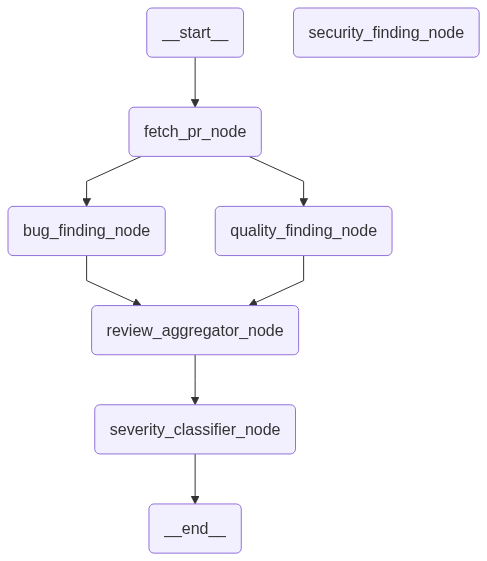

In [102]:
workflow

In [ ]:
initial_state = {"repo_name":"hamzafareed123/async-board","pr_title":"","pr_body":"","pr_number":51,"pr_state":"open","files":[]}

result=workflow.invoke(initial_state)


In [ ]:
print(result)

# for i, b in enumerate(result['bug_findings']):
#   print(f"\n========== Bug No {i+1}\n")
#   print(b.file_name)
#   print(b.line_number)
#   print(b.severity)
#   print(b.description)
#   print(b.recommendation)
#   print(b.has_bug)


# for i, s in enumerate(result['security_findings']):
#     print(f"\n========== Security Finding No {i+1}\n")
#     print(s.file_name)
#     print(s.line_number)
#     print(s.vulnerability_type)
#     print(s.severity)
#     print(s.description)
#     print(s.recommendation)


# for i, s in enumerate(result['quality_findings']):
#     print(f"\n========== Quality Finding No {i+1}\n")
#     print(s.file_name)
#     print(s.line_number)
#     print(s.issue_type)
#     print(s.severity)
#     print(s.description)
#     print(s.recommendation)

for i, s in enumerate(result['all_findings']):
    print(f"\n========== Unified Finding No {i+1}\n")
    print(s.source)
    print(s.file_name)
    print(s.line_number)
    print(s.severity)
    print(s.description)
    print(s.recommendation)

print(f"\n========== PR Verdict\n")
print(result['pr_verdict']['overall_severity'])
print(result['pr_verdict']['recommendation'])
print(result['pr_verdict']['findings_count'])